In [35]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Likhi\OneDrive\Desktop\AIRFLY Insights\archive (4)\flights.csv")



c:\Users\Likhi\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3553: DtypeWarning: Columns (7,8) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [36]:
df.shape


(5819079, 32)

In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 32 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  SCHEDULED_TIME       float64
 14  ELAPSED_TIME         float64
 15  AIR_TIME             float64
 16  DISTANCE             int64  
 17  TAXI_IN              float64
 18  SCHEDULED_ARRIVAL    int64  
 19  ARRIVAL_TIME         float64
 20  ARRIVAL_DELAY        float64
 21  DIVERTED             int64  
 22  CANCELLED            int64  
 23  CANCELLATION_REASON  object 
 24

In [38]:
df.isnull().sum()


YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
FLIGHT_NUMBER          0
TAIL_NUMBER            0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
TAXI_IN                0
SCHEDULED_ARRIVAL      0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
DATE                   0
ROUTE                  0
DEPARTURE_HOUR         0
dtype: int64

In [39]:
df.duplicated().sum()


0

In [40]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [41]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [42]:
time_cols = ['DEP_TIME', 'ARR_TIME']

for col in time_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [43]:
df.columns



Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'DATE', 'ROUTE', 'DEPARTURE_HOUR'],
      dtype='object')

In [44]:
time_cols = [
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'WHEELS_OFF',
    'WHEELS_ON',
    'SCHEDULED_ARRIVAL',
    'ARRIVAL_TIME'
]


In [45]:
print(time_cols)

['SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'WHEELS_OFF', 'WHEELS_ON', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME']


In [46]:
valid_cols = [col for col in time_cols if col in df.columns]
df[valid_cols] = df[valid_cols].fillna(df[valid_cols].median())

In [47]:
delay_cols = [
    'AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY','WEATHER_DELAY'
]

df[delay_cols] = df[delay_cols].fillna(0)


In [48]:
df.loc[df['CANCELLED'] == 0, 'CANCELLATION_REASON'] = 'Not Cancelled'
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna('Unknown')

In [49]:
df.drop(columns=['WHEELS_ON'], errors='ignore', inplace=True)

In [51]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,ROUTE,DEPARTURE_HOUR
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-01-01,ANC - SEA,23.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-01-01,LAX - PBI,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-01-01,SFO - CLT,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-01-01,LAX - MIA,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-01-01,SEA - ANC,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-12-31,LAX - BOS,23.0
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-12-31,JFK - PSE,23.0
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-12-31,JFK - SJU,23.0
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,0,Not Cancelled,2.0,0.0,2.0,3.0,0.0,2015-12-31,MCO - SJU,23.0


In [52]:
df["DATE"] = pd.to_datetime(df[["YEAR","MONTH","DAY"]])

In [53]:
df[["YEAR","MONTH","DAY","DATE"]]

,YEAR,MONTH,DAY,DATE
0,2015,1,1,2015-01-01
1,2015,1,1,2015-01-01
2,2015,1,1,2015-01-01
3,2015,1,1,2015-01-01
4,2015,1,1,2015-01-01
...,...,...,...,...
5819074,2015,12,31,2015-12-31
5819075,2015,12,31,2015-12-31
5819076,2015,12,31,2015-12-31
5819077,2015,12,31,2015-12-31


In [54]:
df.isnull().sum()


YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
FLIGHT_NUMBER          0
TAIL_NUMBER            0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
TAXI_IN                0
SCHEDULED_ARRIVAL      0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
DATE                   0
ROUTE                  0
DEPARTURE_HOUR         0
dtype: int64

In [55]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'DATE', 'ROUTE', 'DEPARTURE_HOUR'],
      dtype='object')

In [56]:
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + " - " + df['DESTINATION_AIRPORT'].astype(str)

In [57]:
df[['ORIGIN_AIRPORT','DESTINATION_AIRPORT','ROUTE']].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,ANC,SEA,ANC - SEA
1,LAX,PBI,LAX - PBI
2,SFO,CLT,SFO - CLT
3,LAX,MIA,LAX - MIA
4,SEA,ANC,SEA - ANC


## Week 3

### 1. Top Airlines by Number of Flights (Univariate)

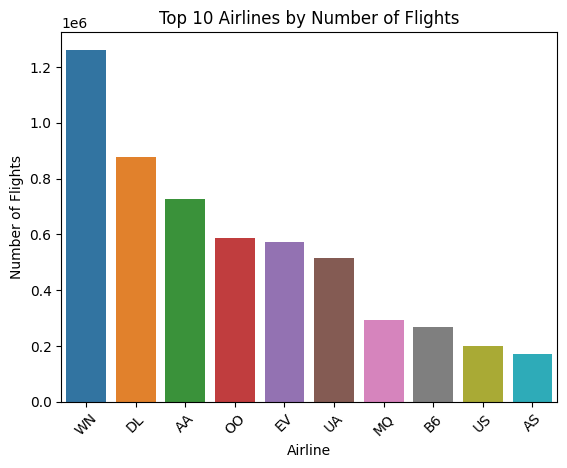

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count flights per airline
airline_counts = df['AIRLINE'].value_counts().head(10)

plt.figure()
sns.barplot(x=airline_counts.index, y=airline_counts.values)
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

### Observations – Top 10 Airlines by Number of Flights

From the above bar chart, it is clearly observed that WN (Southwest Airlines) operates the highest number of flights among all airlines in the dataset. It has a significantly larger operational volume compared to other carriers.

DL (Delta Airlines) and AA (American Airlines) follow as the second and third most active airlines. However, there is a noticeable gap between WN and the rest of the airlines, indicating that flight operations are not evenly distributed.

Airlines such as US and AS operate comparatively fewer flights, suggesting a smaller operational scale within this dataset.

Overall, flight operations are concentrated among a few major carriers. Therefore, the performance and delay patterns of these top airlines will have a strong impact on overall air traffic analysis.

## 2. Airline vs Average Departure Delay (Bivariate)

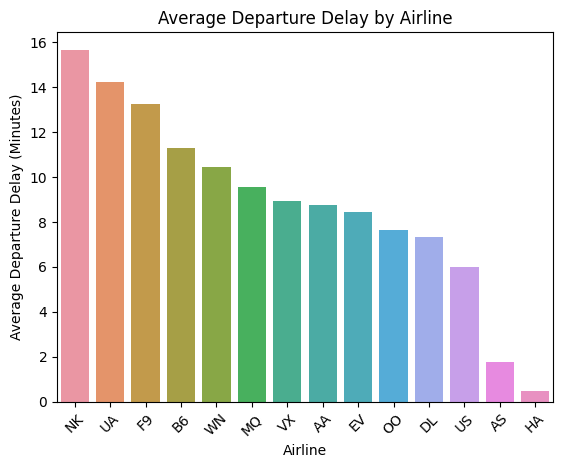

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average departure delay per airline
avg_delay = df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

plt.figure()
sns.barplot(x=avg_delay.index, y=avg_delay.values)
plt.title("Average Departure Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Departure Delay (Minutes)")
plt.xticks(rotation=45)
plt.show()

### Observations – Average Departure Delay by Airline

The above bar chart compares the average departure delay across different airlines. It is observed that NK has the highest average departure delay, followed by UA and F9. This indicates that flights operated by these airlines tend to experience longer departure delays on average.

On the other hand, airlines such as HA and AS show significantly lower average departure delays, suggesting better departure punctuality compared to other carriers.

There is a clear variation in delay performance among airlines, indicating that operational efficiency differs across carriers. This analysis helps identify delay-prone airlines and those with better on-time performance.

## 3. Flights Distribution by Month (Univariate)

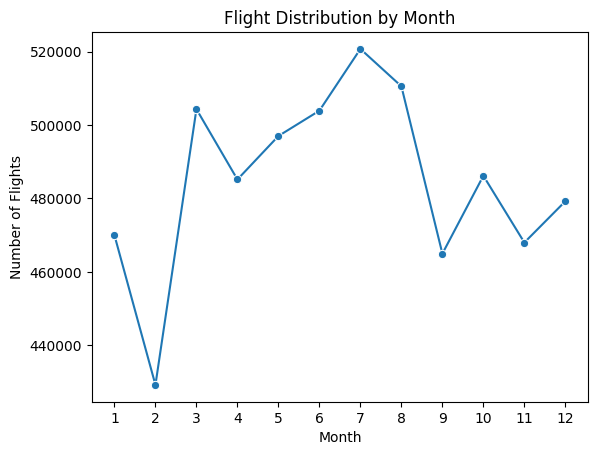

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count flights per month
monthly_counts = df['MONTH'].value_counts().sort_index()

plt.figure()
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o')
plt.title("Flight Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(range(1,13))
plt.show()

### Observations – Flight Distribution by Month

The line plot shows the distribution of flights across different months. It is observed that flight operations peak around Month 7, indicating the highest air traffic during this period.

Month 2 records the lowest number of flights, suggesting comparatively reduced travel activity. After Month 7, there is a noticeable decline in flight count, followed by moderate fluctuations in the remaining months.

Overall, the graph indicates seasonal variation in air traffic, where certain months experience significantly higher operational demand. These peak months may correspond to holiday seasons or increased travel demand.

## 4. Flight Distribution by Day of Week (Univariate)

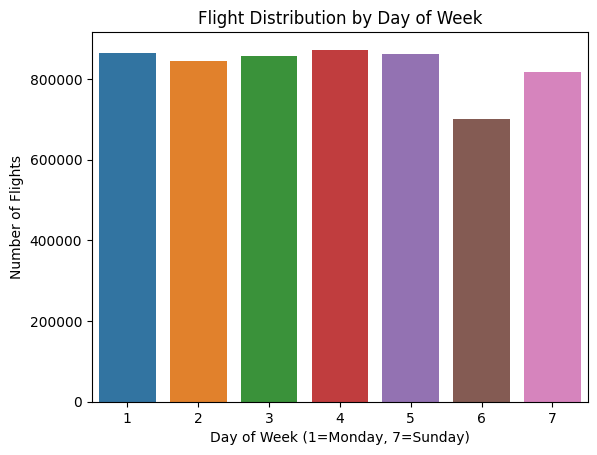

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count flights per day of week
day_counts = df['DAY_OF_WEEK'].value_counts().sort_index()

plt.figure()
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title("Flight Distribution by Day of Week")
plt.xlabel("Day of Week (1=Monday, 7=Sunday)")
plt.ylabel("Number of Flights")
plt.show()

### Observations – Flight Distribution by Day of Week

The bar chart shows the distribution of flights across different days of the week. It is observed that flight operations remain relatively consistent from Day 1 to Day 5, indicating stable weekday traffic.

Day 4 records the highest number of flights, while Day 6 shows a noticeable drop in operations compared to other days. This suggests slightly reduced travel activity during that day.

Overall, flight traffic appears to be evenly distributed throughout the week with minor fluctuations. This indicates consistent operational demand rather than extreme weekday or weekend dominance.

## 5. Departure Delay Distribution (Univariate)

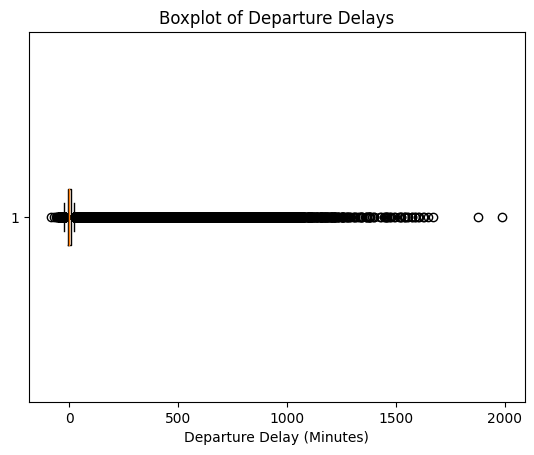

In [62]:
plt.figure()
plt.boxplot(df['DEPARTURE_DELAY'].dropna(), vert=False)
plt.title("Boxplot of Departure Delays")
plt.xlabel("Departure Delay (Minutes)")
plt.show()

### Observations – Boxplot of Departure Delays

The boxplot shows that the majority of departure delays are concentrated near zero minutes, indicating that most flights depart on time or with small delays.

However, there are a large number of extreme outliers extending far beyond the upper whisker. Some delays reach very high values, indicating rare but severe delay incidents.

The distribution is highly right-skewed, meaning that while most flights experience minimal delay, a small number of flights experience significantly large delays.

This suggests that although average delays may appear moderate, extreme delay events can heavily impact overall performance analysis.

## Week 4

## 1. Average Delay Causes by Airline

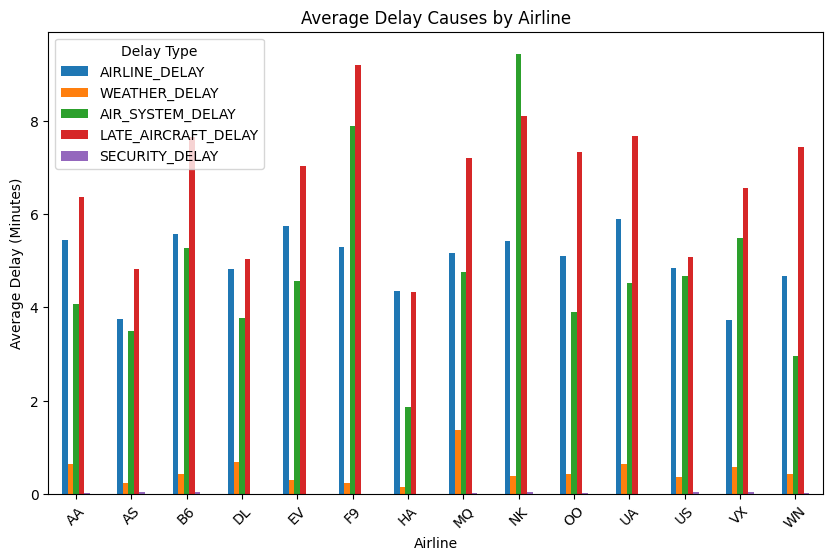

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by airline and calculate average of delay causes
delay_causes = df.groupby('AIRLINE')[[
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'SECURITY_DELAY'
]].mean()

# Plot
delay_causes.plot(kind='bar', figsize=(10,6))
plt.title("Average Delay Causes by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.legend(title="Delay Type")
plt.show()

### Observations – Average Delay Causes by Airline

The grouped bar chart compares different delay causes across airlines. It is observed that LATE_AIRCRAFT_DELAY contributes significantly to overall delays for most airlines, making it one of the dominant delay factors.

AIR_SYSTEM_DELAY is also relatively high for certain airlines such as NK and F9, indicating operational or air traffic control-related constraints. AIRLINE_DELAY shows moderate contribution across most carriers, suggesting internal operational inefficiencies like crew or maintenance delays.

WEATHER_DELAY and SECURITY_DELAY contribute comparatively less to total delays, although weather impact varies slightly across airlines.

Overall, the analysis indicates that operational and aircraft-related factors are the primary contributors to flight delays rather than security or weather factors in most cases.

## 2. Weather Delay Trend by Month(Time Based)

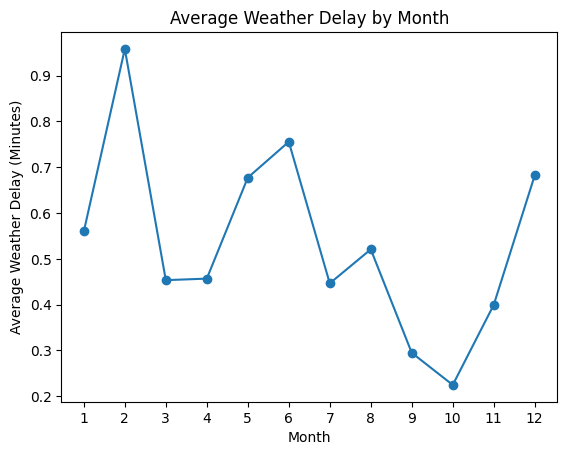

In [64]:
import matplotlib.pyplot as plt

# Calculate average weather delay per month
weather_month = df.groupby('MONTH')['WEATHER_DELAY'].mean()

plt.figure()
plt.plot(weather_month.index, weather_month.values, marker='o')
plt.title("Average Weather Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Weather Delay (Minutes)")
plt.xticks(range(1,13))
plt.show()

### Observations – Average Weather Delay by Month

The line plot shows variation in average weather delay across different months. It is observed that Month 2 records the highest average weather delay, indicating stronger weather impact during this period.

Weather delays decrease noticeably around Months 9 and 10, where the average delay reaches its lowest values. After Month 10, there is a gradual increase again toward Month 12.

Overall, the graph indicates that weather-related delays follow a seasonal pattern, with certain months experiencing higher atmospheric or climatic disturbances affecting flight operations.

## 3. Average Departure Delay by Hour of Day (Time Based)

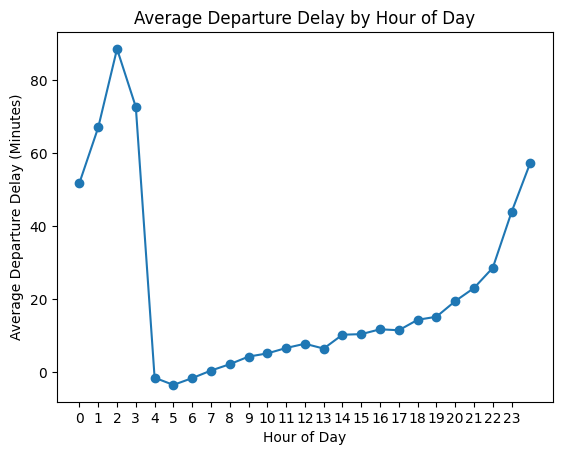

In [65]:
# Extract hour from departure time (assuming HHMM format)
df['DEPARTURE_HOUR'] = df['DEPARTURE_TIME'] // 100

# Calculate average delay per hour
hourly_delay = df.groupby('DEPARTURE_HOUR')['DEPARTURE_DELAY'].mean()

import matplotlib.pyplot as plt

plt.figure()
plt.plot(hourly_delay.index, hourly_delay.values, marker='o')
plt.title("Average Departure Delay by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Departure Delay (Minutes)")
plt.xticks(range(0,24))
plt.show()

### Observations – Average Departure Delay by Hour of Day

The line plot shows how average departure delays vary throughout the day. It is observed that delays are extremely high during the early hours (around 1 AM to 3 AM), indicating significant operational disruptions during late-night or early-morning periods.

From around 4 AM to 7 AM, delays drop sharply and remain relatively low during early morning hours. As the day progresses, delays gradually increase from afternoon to late evening.

There is a noticeable rise again after 8 PM, suggesting that delay accumulation occurs as flights operate throughout the day. Overall, delays tend to build up over time due to congestion and late aircraft arrivals.

## 4. Top Delay-Prone Airlines

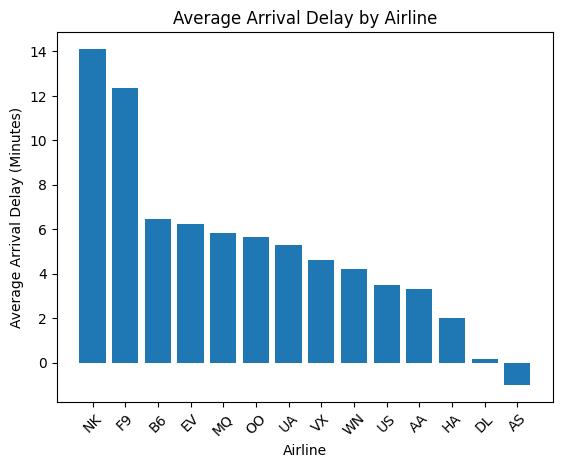

In [66]:
import matplotlib.pyplot as plt

# Calculate average arrival delay per airline
arrival_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

plt.figure()
plt.bar(arrival_delay.index, arrival_delay.values)
plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(rotation=45)
plt.show()

### Observations – Average Arrival Delay by Airline

The bar chart shows the overall average arrival delay for each airline. It is observed that NK has the highest average arrival delay, followed by F9. This indicates that these airlines are more delay-prone compared to others in the dataset.

Airlines such as DL and AS show very low or near-zero average arrival delays, suggesting better on-time arrival performance. The variation across airlines highlights differences in operational efficiency and delay management strategies.

Overall, the analysis clearly identifies top delay-prone carriers and airlines with better punctuality performance.

# Milestone 3: Route, Cancellation, and Seasonal Insights

## Week 5: Route and Airport-Level Analysis 


### 1. Top 10 Origin-Destination Routes

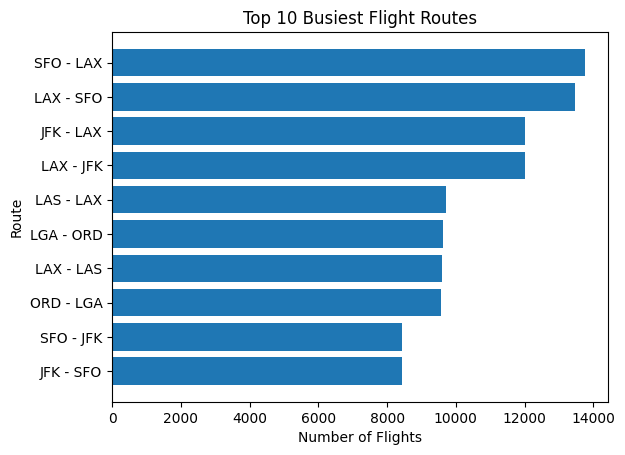

In [67]:
import matplotlib.pyplot as plt
# Count routes
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure()
plt.barh(top_routes.index, top_routes.values)
plt.title("Top 10 Busiest Flight Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.gca().invert_yaxis()
plt.show()

#### Observations – Top 10 Busiest Flight Routes

This bar chart shows the top 10 busiest origin–destination flight routes in the dataset.  
From the graph, the **SFO–LAX route has the highest number of flights**, followed closely by **LAX–SFO**, indicating strong traffic between these two major airports.

Routes such as **JFK–LAX and LAX–JFK** also show very high flight counts, highlighting heavy travel demand between major coastal cities in the United States.

Overall, most of the busiest routes involve **major hub airports**, suggesting that airline traffic is highly concentrated between key metropolitan airports.

### 2. Busiest Origin Airports


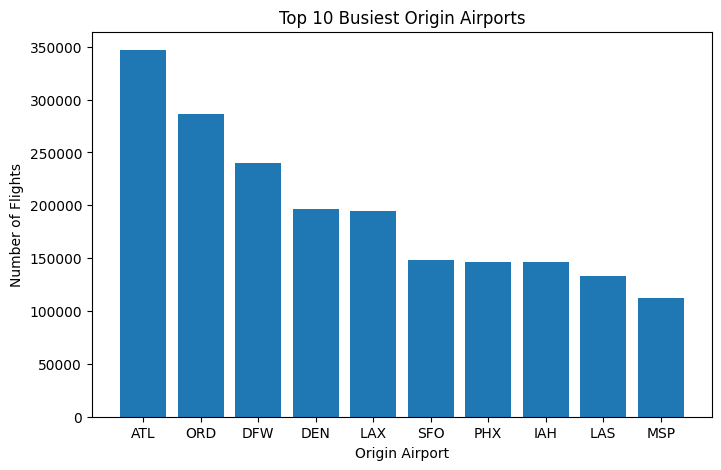

In [68]:
import matplotlib.pyplot as plt

# Count flights per origin airport
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10)

# Plot
plt.figure(figsize=(8,5))
plt.bar(top_airports.index.astype(str), top_airports.values)
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Origin Airport")
plt.ylabel("Number of Flights")
plt.show()

#### Observations – Top 10 Busiest Origin Airports

This bar chart displays the top 10 airports with the highest number of departing flights.  
From the graph, **ATL (Atlanta International Airport)** has the highest number of flights, making it the busiest origin airport in the dataset.

Airports such as **ORD, DFW, DEN, and LAX** also show a large number of departing flights, indicating that these airports serve as major airline hubs.

Overall, the busiest airports are large metropolitan hubs that handle heavy passenger traffic and connect multiple domestic and international routes.

### 3. Delay Heatmap by Origin Airport


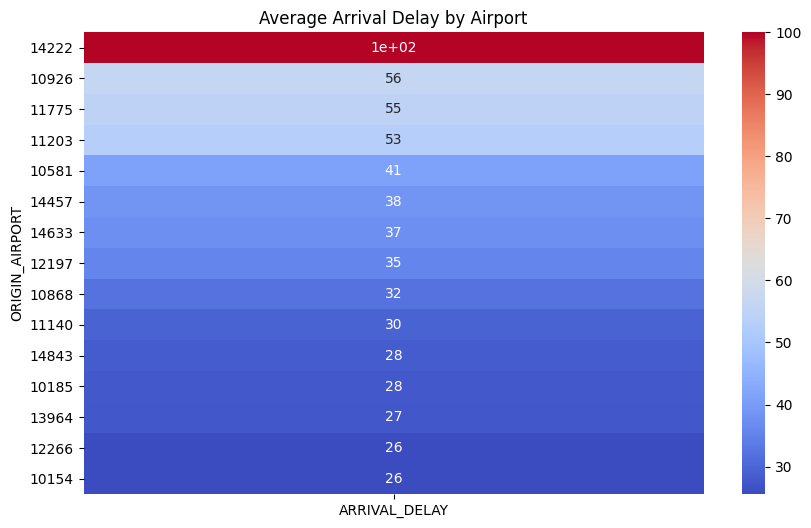

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average delay per airport
delay_airport = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.heatmap(delay_airport.to_frame(), annot=True, cmap='coolwarm')
plt.title("Average Arrival Delay by Airport")
plt.show()

#### Observations – Delay Heatmap by Airport

This heatmap shows the average arrival delay for the top airports in the dataset.  
Airports displayed in darker red colors indicate higher average delays, while cooler colors represent lower delay values.

From the visualization, some airports experience significantly higher delays compared to others, indicating possible congestion or operational challenges at those locations.

The variation in delay intensity across airports highlights that airport-level factors such as traffic volume, weather conditions, and operational efficiency can strongly influence flight delays.

## Week 6: Seasonal and Cancellation Analysis 

### 1. Monthly Cancellation Trends

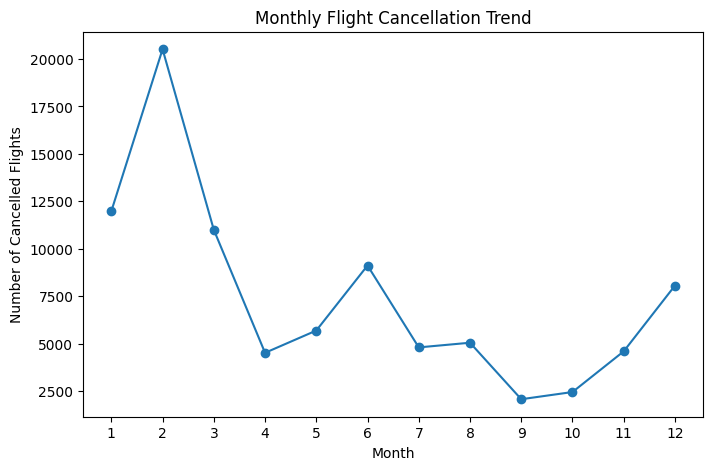

In [70]:
import matplotlib.pyplot as plt

# Count cancellations by month
monthly_cancel = df.groupby('MONTH')['CANCELLED'].sum()

# Plot
plt.figure(figsize=(8,5))
plt.plot(monthly_cancel.index, monthly_cancel.values, marker='o')
plt.title("Monthly Flight Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Cancelled Flights")
plt.xticks(range(1,13))
plt.show()

#### Observations – Monthly Flight Cancellation Trend

This line graph shows how the number of cancelled flights changes across different months.

From the graph, Month 2 has the highest number of cancellations, indicating that flight disruptions are more frequent during this period. This could be influenced by seasonal factors such as winter weather conditions.

Cancellations decrease significantly around Months 9 and 10, showing relatively stable flight operations during these months.

Overall, the trend suggests that flight cancellations follow a seasonal pattern, with certain months experiencing higher disruption levels than others.

### 2. Cancellation Reasons Analysis

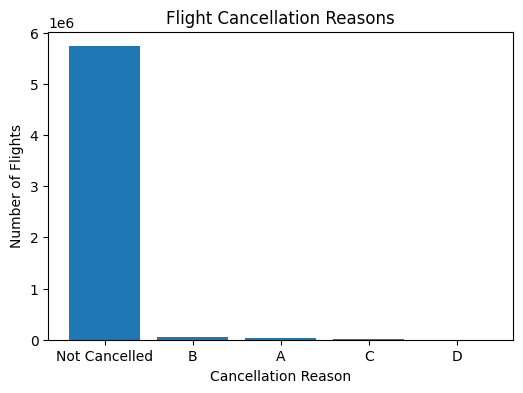

In [71]:
import matplotlib.pyplot as plt

# Count cancellation reasons
cancel_reasons = df['CANCELLATION_REASON'].value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(cancel_reasons.index.astype(str), cancel_reasons.values)
plt.title("Flight Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Flights")
plt.show()

#### Observations – Flight Cancellation Reasons

This bar chart shows the different reasons for flight cancellations in the dataset.

The majority of flights fall under the "Not Cancelled" category, indicating that most flights operate as scheduled without cancellation.

Among the cancelled flights, reason **B (Weather-related cancellations)** appears more frequently compared to other reasons. This suggests that weather conditions are a significant factor affecting flight operations.

Other cancellation reasons such as **A (Airline/Carrier issues)**, **C (Air System delays)**, and **D (Security-related issues)** occur less frequently.

Overall, the visualization highlights that while cancellations are relatively rare compared to completed flights, weather-related factors play an important role in flight disruptions.

### 3. Seasonal Delay Trend by Month

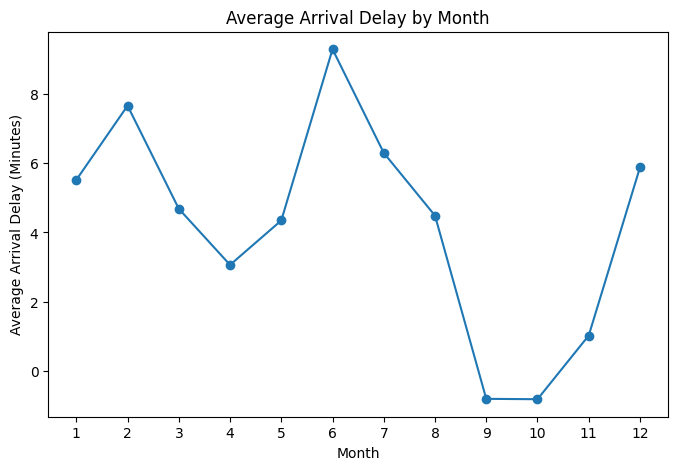

In [72]:
import matplotlib.pyplot as plt

# Calculate average arrival delay by month
monthly_delay = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()

# Plot
plt.figure(figsize=(8,5))
plt.plot(monthly_delay.index, monthly_delay.values, marker='o')
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(range(1,13))
plt.show()

#### Observations – Average Arrival Delay by Month

This line graph shows how the average arrival delay varies across different months of the year.

From the graph, Month 6 has the highest average delay, indicating that flight disruptions are more frequent during this period. Months 2 and 7 also show relatively higher delays compared to other months.

In contrast, Months 9 and 10 show very low or slightly negative delays, suggesting better on-time performance during these months.

Overall, the visualization indicates that flight delays follow seasonal patterns, where certain months experience higher delays possibly due to increased travel demand or weather-related disruptions.

In [73]:
df.to_csv("flights.csv",index=False)